## Problem Statement
*To create a classification model to predict weather the bank client will subscribe to a term deposit(Yes/No) based on their demographic, financial, and previous contact information, so that marketing team can target the most promising clients and reduce the number of unsuccessful calls.*

| Name        | Role    | Type        | Units | Description                                                                                                                                                                                                                                                                                                                                                                                                        | Missing Values |
| ----------- | ------- | ----------- | ----- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------- |
| age         | feature | integer     |       |                                                                                                                                                                                                                                                                                                                                                                                                                    | No             |
| job         | feature | categorical |       | type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')                                                                                                                                                                                                                                       | No             |
| marital     | feature | categorical |       | marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)                                                                                                                                                                                                                                                                                                  | No             |
| education   | feature | categorical |       | (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')                                                                                                                                                                                                                                                                                     | No             |
| default     | feature | binary      |       | has credit in default?                                                                                                                                                                                                                                                                                                                                                                                             | No             |
| balance     | feature | integer     | euros | average yearly balance                                                                                                                                                                                                                                                                                                                                                                                             | No             |
| housing     | feature | binary      |       | has housing loan?                                                                                                                                                                                                                                                                                                                                                                                                  | No             |
| loan        | feature | binary      |       | has personal loan?                                                                                                                                                                                                                                                                                                                                                                                                 | No             |
| contact     | feature | categorical |       | contact communication type (categorical: 'cellular','telephone')                                                                                                                                                                                                                                                                                                                                                   | Yes            |
| day | feature | date        |       | last contact day of the week                                                                                                                                                                                                                                                                                                                                                                                       | No             |
| month       | feature | date        |       | last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')                                                                                                                                                                                                                                                                                                                                   | No             |
| duration    | feature | integer     |       | last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. | No             |
| campaign    | feature | integer     |       | number of contacts performed during this campaign and for this client (numeric, includes last contact)                                                                                                                                                                                                                                                                                                             | No             |
| pdays       | feature | integer     |       | number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)                                                                                                                                                                                                                                                                 | Yes            |
| previous    | feature | integer     |       | number of contacts performed before this campaign and for this client                                                                                                                                                                                                                                                                                                                                              | No             |
| poutcome    | feature | categorical |       | outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')                                                                                                                                                                                                                                                                                                                        | Yes            |
| y           | target  | binary      |       | has the client subscribed a term deposit?                                                                                                                                                                                                                                                                                                                                                                          | No             |

## Load The dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

ACCENT  = "#38bdf8"   # sky-blue
ACCENT2 = "#f472b6"   # pink
ACCENT3 = "#34d399"   # emerald
ACCENT4 = "#fb923c"   # orange
PALETTE = [ACCENT, ACCENT2, ACCENT3, ACCENT4, "#a78bfa", "#fbbf24"]

In [10]:
df = pd.read_csv('../datasets/raw/bank-full.csv', sep=';')
print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df.head()

Dataset shape : 45,211 rows × 17 columns
Memory usage  : 27.00 MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Data Cleaning

In [12]:
# Check missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing >= 0].to_string())
print(f"\nTotal missing cells: {missing.sum()}")

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0

Total missing cells: 0


In [13]:
# Encode categorical variables
print("Target class distribution (%):")
print(df["y"].value_counts()/len(df)*100)
print(f"\nImbalance ratio: {df['y'].value_counts()['no'] / df['y'].value_counts()['yes']:.1f} : 1")

Target class distribution (%):
y
no     88.30152
yes    11.69848
Name: count, dtype: float64

Imbalance ratio: 7.5 : 1


**Key decisions:**
- **`unknown` values** in categorical columns are retained as a valid category (they carry signal).
- **`pdays == -1`** means the client was never previously contacted → extract a binary flag, then replace -1 with 0.
- **`default`** column is highly imbalanced (99.8 % `no`) but kept for feature completeness.
- Encode the binary target `y` → `y_binary` (1 = yes, 0 = no).

In [14]:
df['job']=np.where(df['job']=='admin.', 'admin', df['job'])

In [15]:
# Clients previously contacted
prev_contacted = (df["pdays"] != -1)
print(f"Clients previously contacted : {prev_contacted.sum():,}"
      f" ({100 * prev_contacted.mean():.1f} %)")

# Clients NOT previously contacted
print(f"Clients NOT previously contacted: {(df['pdays'] == -1).sum():,}")

# Replace -1 with 0 (after extracting the flag)
df["pdays"] = df["pdays"].replace(-1, 0)

Clients previously contacted : 8,257 (18.3 %)
Clients NOT previously contacted: 36,954


In [16]:
print(f"Shape after cleaning : {df.shape}")
print(f"Null values remaining: {df.isnull().sum().sum()}")
df.head(3)

Shape after cleaning : (45211, 17)
Null values remaining: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,0,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,0,0,unknown,no


## Exploratory Data Analysis

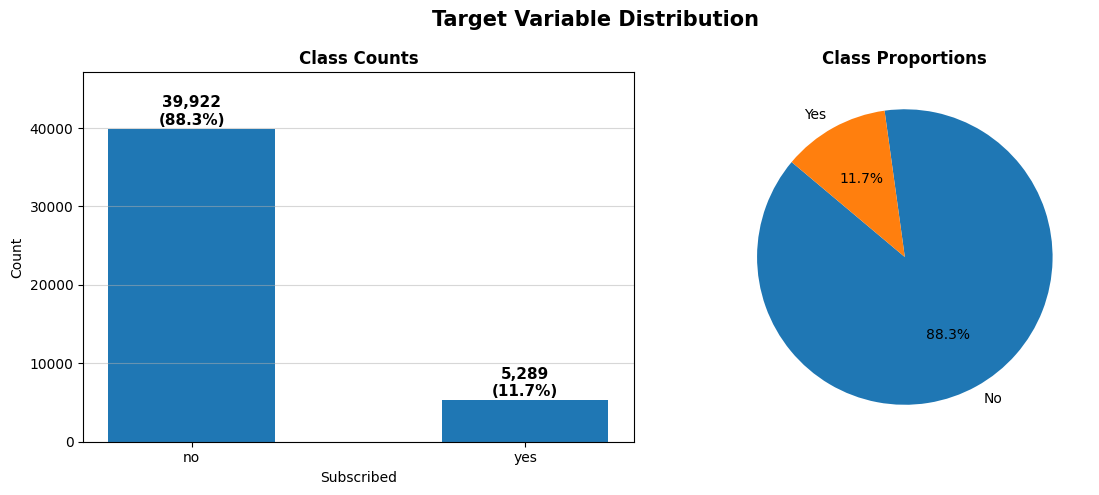

In [17]:
# Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Target Variable Distribution", fontsize=15,fontweight="bold")

counts = df["y"].value_counts()

# Bar chart
axes[0].bar(counts.index, counts.values, width=0.5, linewidth=1.5)
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 500, f"{v:,}\n({100*v/len(df):.1f}%)", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Class Counts", fontweight="bold")
axes[0].set_xlabel("Subscribed"); axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].grid(axis="y", alpha=0.5)

# Pie chart
axes[1].pie(counts.values, autopct="%1.1f%%", startangle=140, labels=['No', 'Yes'])
axes[1].set_title("Class Proportions", fontweight="bold")

plt.tight_layout()
plt.show()

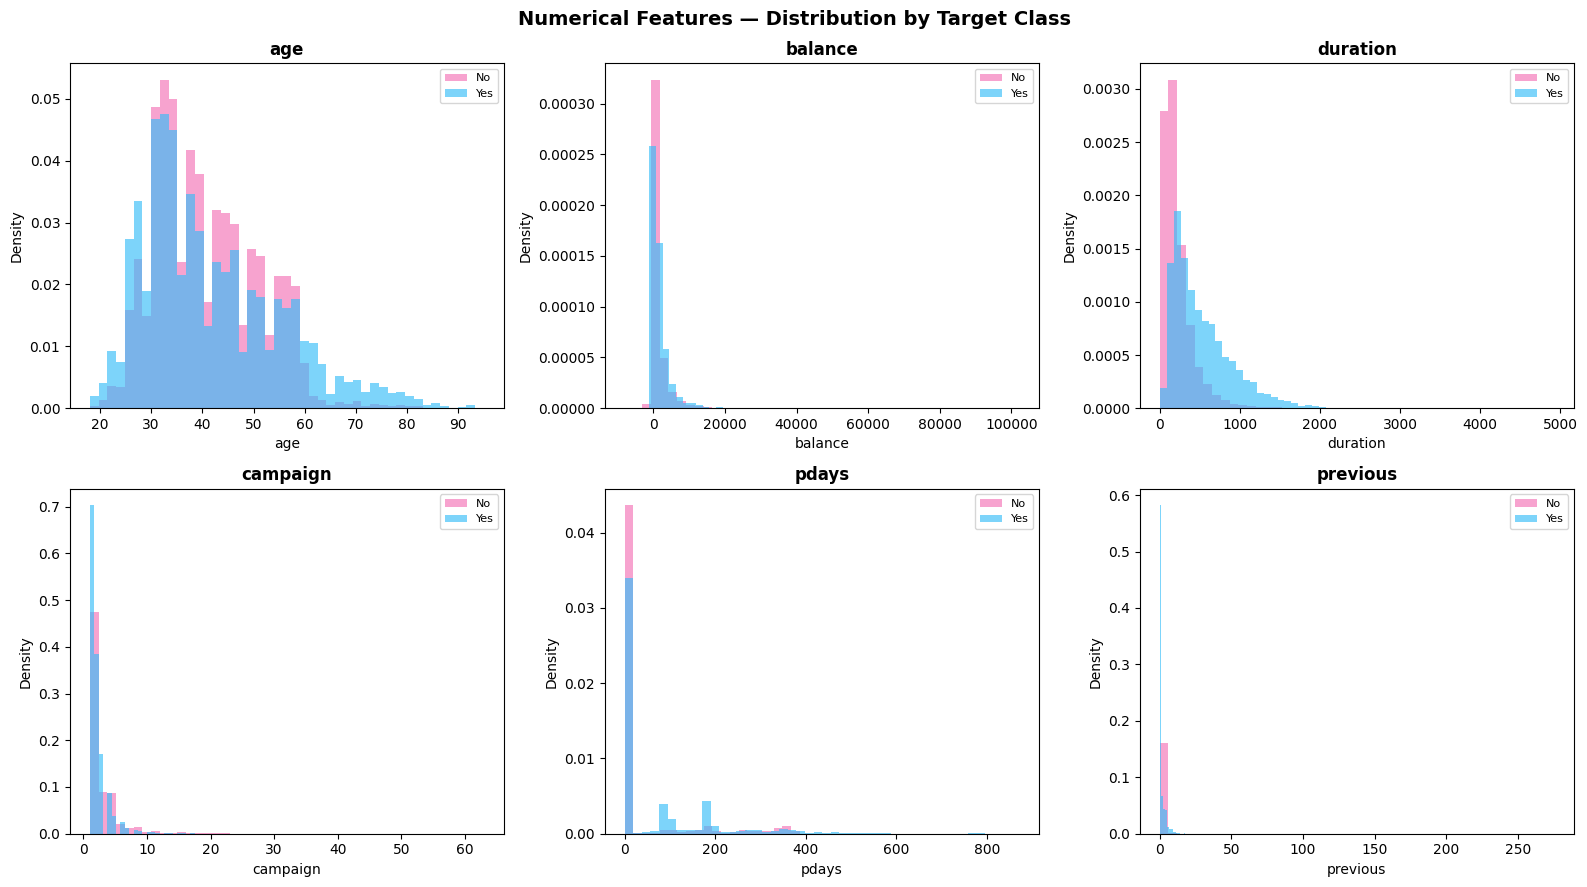

In [18]:
# Numerical Feature Distributions by Target
NUM_COLS = ["age", "balance", "duration", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Numerical Features — Distribution by Target Class", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    yes_v = df.loc[df["y"] == 'yes', col]
    no_v  = df.loc[df["y"] == 'no',  col]
    axes[i].hist(no_v,  bins=45, alpha=0.65, color="#f472b6", label="No",  density=True)
    axes[i].hist(yes_v, bins=45, alpha=0.65, color="#38bdf8", label="Yes", density=True)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel(col); axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
# Encode binary target
df["y"] = (df["y"] == "yes").astype(int)

print("Target encoding:")
print(df["y"].value_counts().rename({0: "no (0)", 1: "yes (1)"}))

Target encoding:
y
no (0)     39922
yes (1)     5289
Name: count, dtype: int64


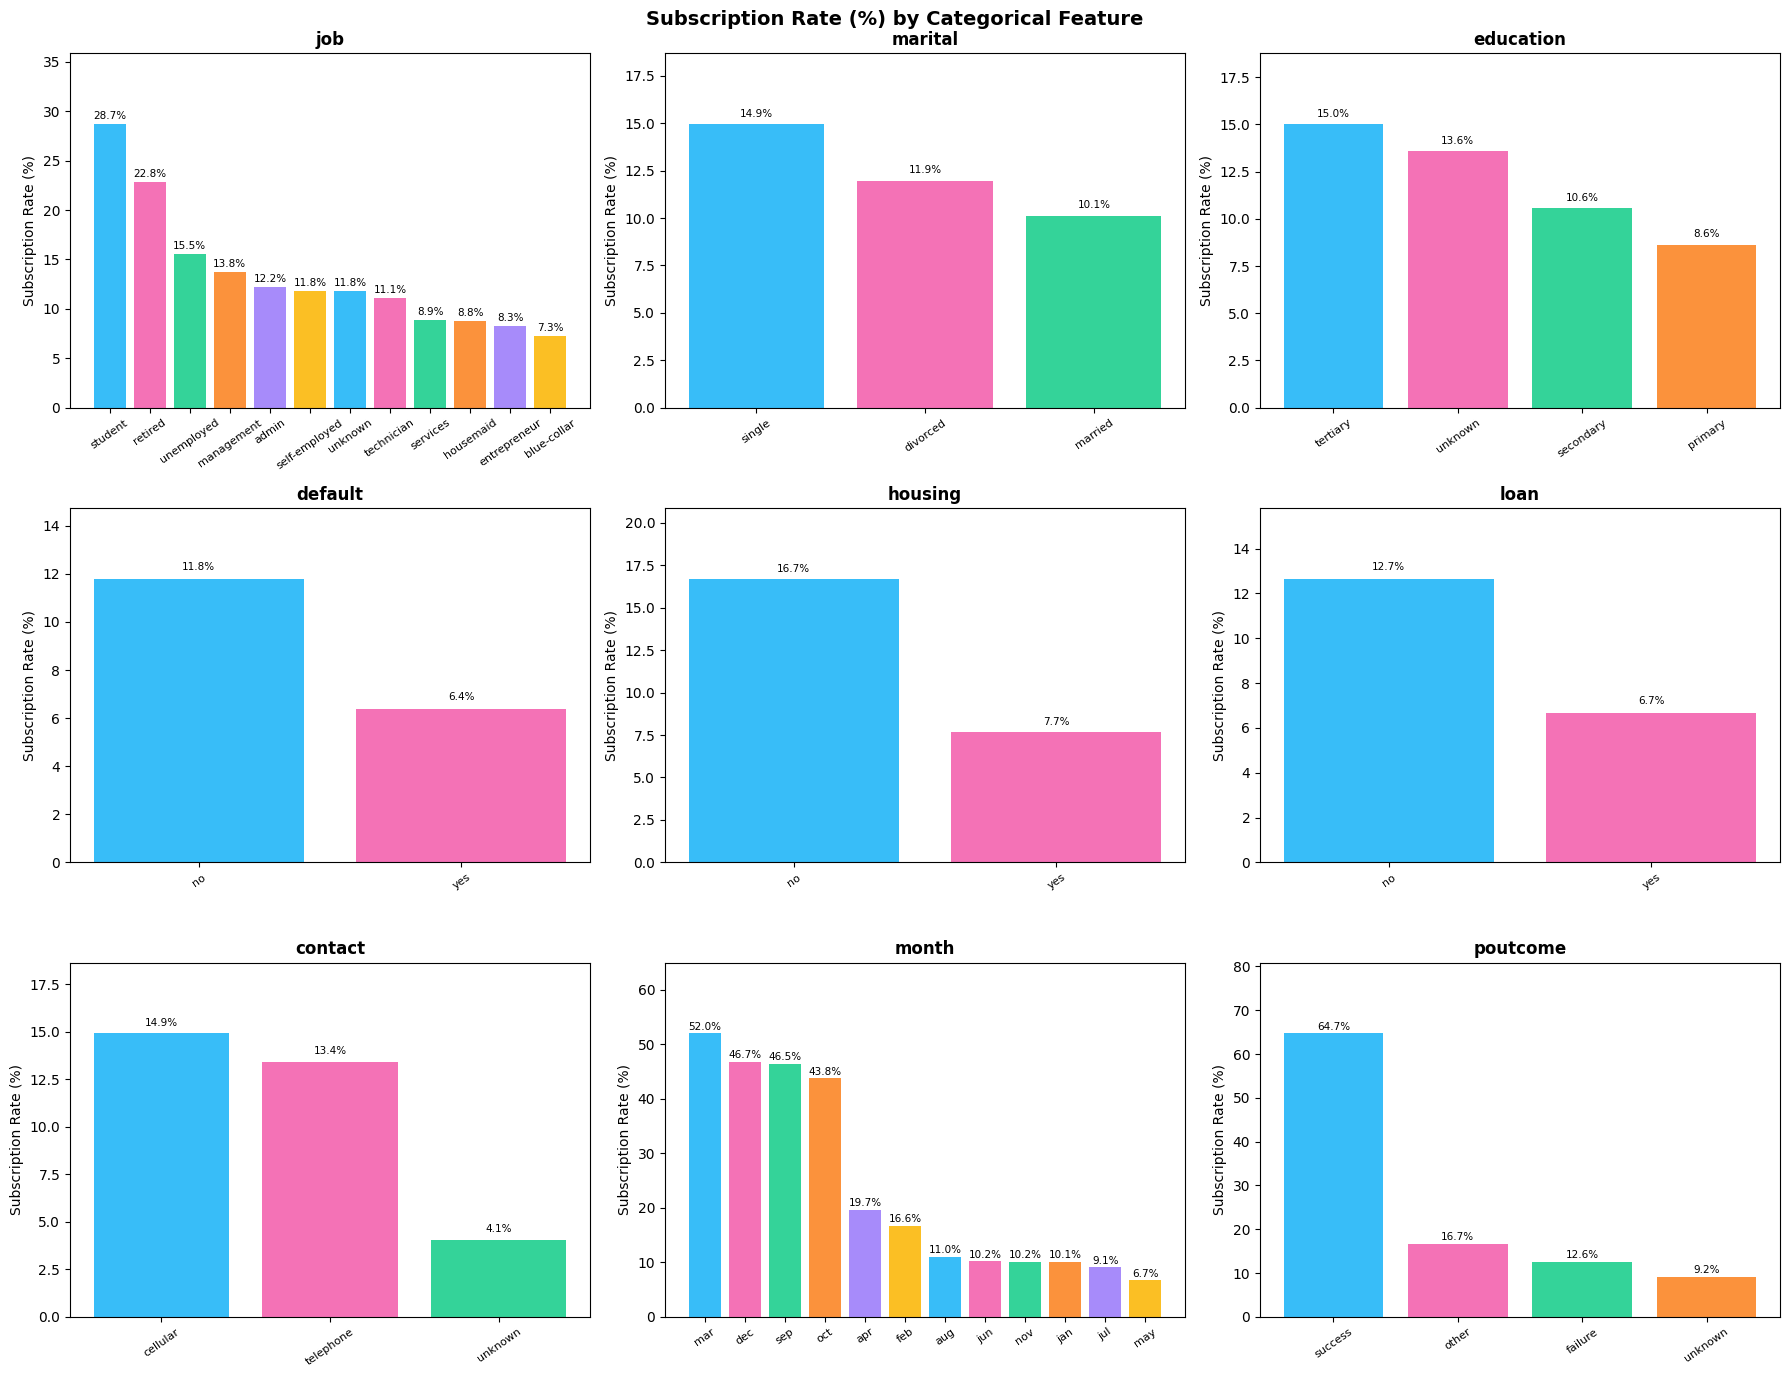

In [20]:
# Categorical Feature Subscription Rates
CAT_COLS = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Subscription Rate (%) by Categorical Feature", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    rates = (df.groupby(col)["y"].mean() * 100).sort_values(ascending=False)
    bars  = axes[i].bar(rates.index, rates.values, color=PALETTE[:len(rates)], linewidth=1)
    for bar, val in zip(bars, rates.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{val:.1f}%", ha="center", va="bottom", fontsize=7.5)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("Subscription Rate (%)")
    axes[i].tick_params(axis="x", rotation=35, labelsize=8)
    axes[i].set_ylim(0, rates.max() * 1.25)

plt.tight_layout()
plt.show()

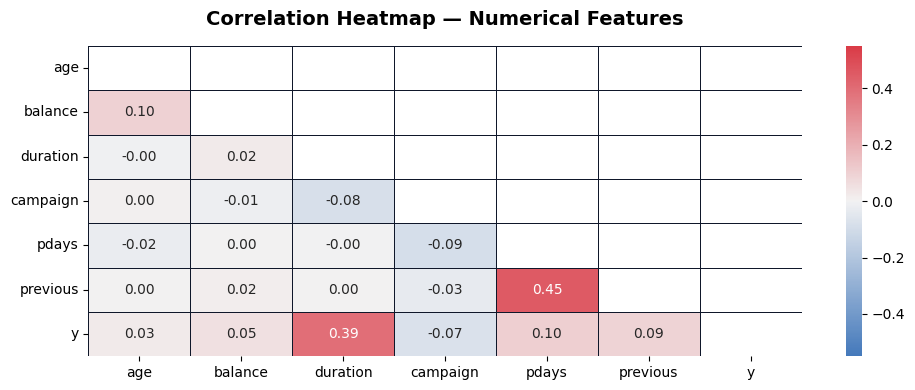

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
corr = df[NUM_COLS + ["y"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(
    corr, mask=mask, cmap=cmap, vmax=0.55, vmin=-0.55, center=0,
    annot=True, fmt=".2f", linewidths=0.5,
    linecolor="#0f172a", ax=ax, annot_kws={"size": 10}
)
ax.set_title("Correlation Heatmap — Numerical Features",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

**Key insights:**
- **`duration :`** Strongest predictor — longer call = higher subscription chance
- **`campaign :`** Negative signal — more calls this campaign = lower conversion
- **`poutcome :`** Previous success is the best categorical predictor
- **`month :`** Mar / Sep / Oct / Dec show highest conversion rates
- **`job :`** Students & retired clients subscribe most often
- **`balance :`** Wealthier clients (higher balance) trend toward 'yes'

## Outlier Detection
### Strategy (scenario-aware)
| Feature | Decision | Reason |
|---------|----------|--------|
| `balance` | Winsorize (1st–99th pct) | Legitimate negatives (overdrafts) + extreme wealth; cap extremes |
| `duration` | Winsorize (1st–99th pct) | Very long calls are real but extreme values distort distance metrics |
| `campaign` | Winsorize (1st–99th pct) | >30 contacts per campaign is operationally implausible |
| `previous` | Winsorize (1st–99th pct) | Extreme values are encoding errors |
| `pdays` | Winsorize (1st–99th pct) | Days since last contact > 2 years is noise |
| `age` | **No treatment** | Max 95 is a valid senior-citizen age — removing harms elderly segment |

In [22]:
df_clean = df.copy()
cap_cols = ["balance", "campaign", "duration", "previous", "pdays"]
cap_values = {}

print(f"{'Feature':<12} {'Before range':>22}  {'After range':>22}")
print("-" * 62)
for col in cap_cols:
    lo_p = df_clean[col].quantile(0.01)
    hi_p = df_clean[col].quantile(0.99)
    before = f"[{df_clean[col].min():.0f}, {df_clean[col].max():.0f}]"
    df_clean[col] = df_clean[col].clip(lower=lo_p, upper=hi_p)
    after  = f"[{df_clean[col].min():.0f}, {df_clean[col].max():.0f}]"
    print(f"{col:<12} {before:>22}  {after:>22}")
    cap_values[col] = {'lo': lo_p, 'hi': hi_p}

print("\nAge left unchanged (max=95 is a valid elderly client).")

Feature                Before range             After range
--------------------------------------------------------------
balance             [-8019, 102127]           [-627, 13165]
campaign                    [1, 63]                 [1, 16]
duration                  [0, 4918]              [11, 1269]
previous                   [0, 275]                  [0, 9]
pdays                      [0, 871]                [0, 370]

Age left unchanged (max=95 is a valid elderly client).


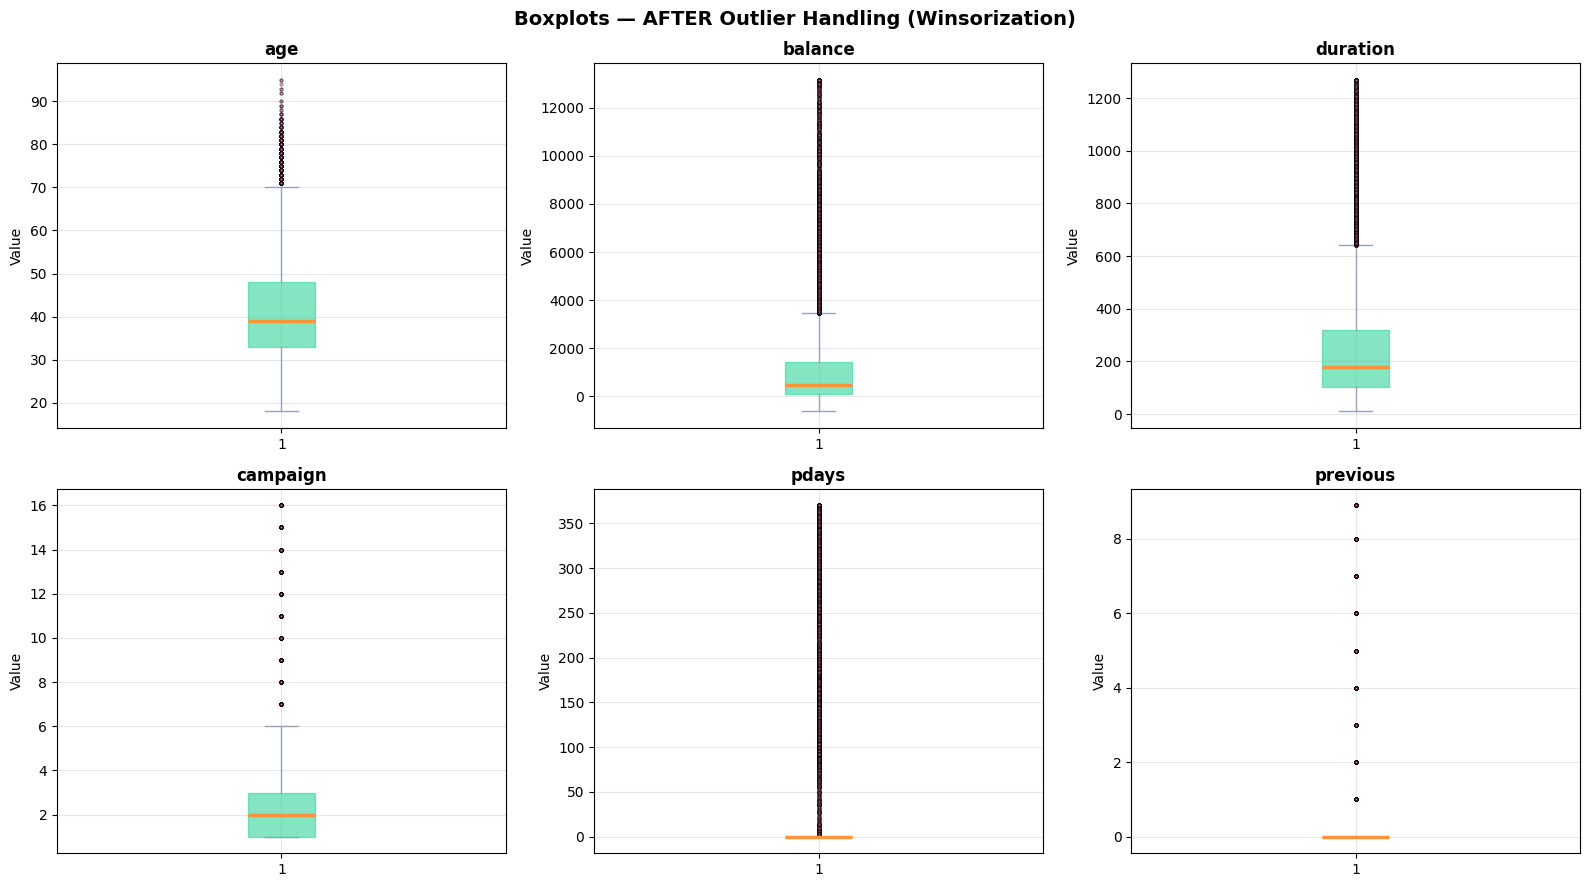

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Boxplots — AFTER Outlier Handling (Winsorization)", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    axes[i].boxplot(
        df_clean[col], patch_artist=True,
        boxprops     = dict(facecolor=ACCENT3, alpha=0.6, color=ACCENT3),
        whiskerprops = dict(color="#94a3b8"),
        capprops     = dict(color="#94a3b8"),
        flierprops   = dict(marker="o", color=ACCENT2,
                            markerfacecolor=ACCENT2, alpha=0.35, markersize=2),
        medianprops  = dict(color=ACCENT4, linewidth=2.5)
    )
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("Value"); axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
skew_before = df_clean[NUM_COLS].skew().sort_values(ascending=False)

print(f"{'Feature':<12} {'Skewness':>10}  {'Verdict':}")
print("-" * 50)
for col, sk in skew_before.items():
    flag = "HIGH — transform" if abs(sk) > 1 else (
           "MODERATE"        if abs(sk) > 0.5 else "OK")
    print(f"{col:<12} {sk:>10.3f}  {flag}")

Feature        Skewness  Verdict
--------------------------------------------------
previous          3.651  HIGH — transform
balance           3.073  HIGH — transform
campaign          2.865  HIGH — transform
pdays             2.343  HIGH — transform
duration          2.077  HIGH — transform
age               0.685  MODERATE


In [25]:
TRANSFORM_COLS = []
for col in NUM_COLS:
    if abs(skew_before[col]) > 1 and col != "balance" and df_clean[col].min() >= 0:
        TRANSFORM_COLS.append(col)

print(f"Applying log1p to: {TRANSFORM_COLS}")

df_transformed = df_clean.copy()
for col in TRANSFORM_COLS:
    df_transformed[col] = np.log1p(df_transformed[col])

skew_after = df_transformed[NUM_COLS].skew()

print(f"\n{'Feature':<12} {'Before':>10} {'After':>10}  {'Improved?'}")
print("-" * 50)
for col in NUM_COLS:
    imp = "+" if abs(skew_after[col]) < abs(skew_before[col]) else "-"
    print(f"{col:<12} {skew_before[col]:>10.3f} {skew_after[col]:>10.3f}  {imp}")

Applying log1p to: ['duration', 'campaign', 'pdays', 'previous']

Feature          Before      After  Improved?
--------------------------------------------------
age               0.685      0.685  -
balance           3.073      3.073  -
duration          2.077     -0.402  +
campaign          2.865      1.154  +
pdays             2.343      1.708  +
previous          3.651      2.322  +


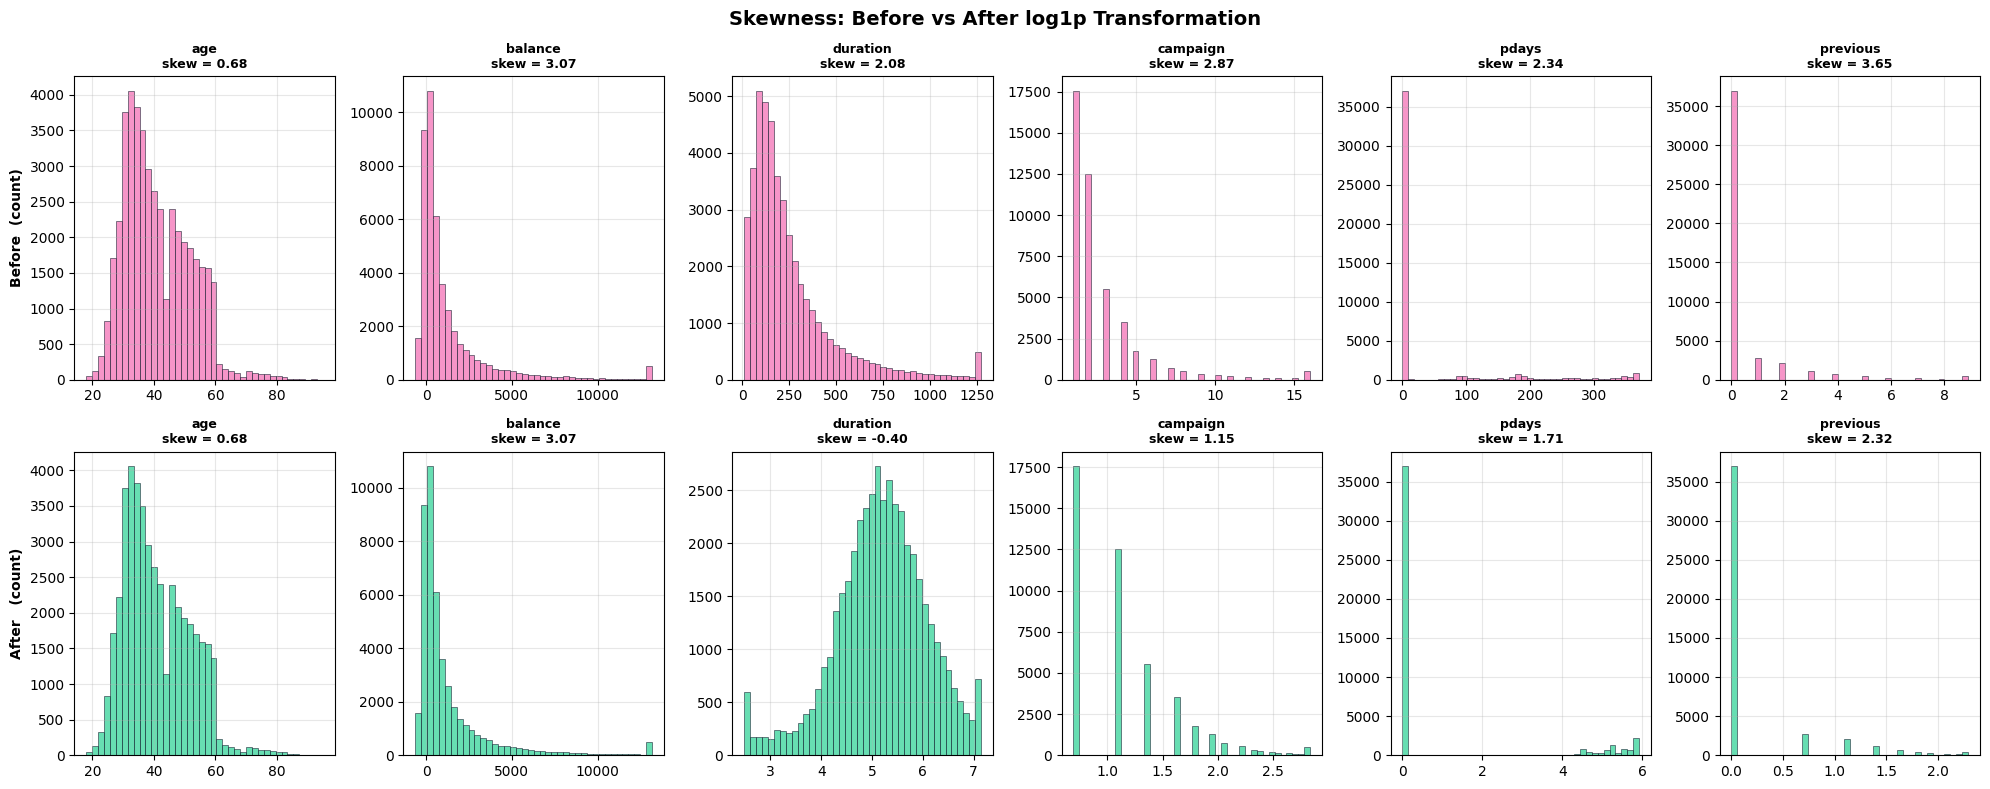

In [26]:
fig, axes = plt.subplots(2, len(NUM_COLS), figsize=(20, 8))
fig.suptitle("Skewness: Before vs After log1p Transformation", fontsize=14, fontweight="bold")

for i, col in enumerate(NUM_COLS):
    # Before
    axes[0, i].hist(
        df_clean[col].replace([np.inf, -np.inf], np.nan).dropna(),
        bins=40, color=ACCENT2, alpha=0.75,
        edgecolor="#0f172a", linewidth=0.5
    )
    axes[0, i].set_title(f"{col}\nskew = {skew_before[col]:.2f}",
                          fontsize=9, fontweight="bold")
    axes[0, i].grid(alpha=0.3)

    # After
    axes[1, i].hist(
        df_transformed[col].replace([np.inf, -np.inf], np.nan).dropna(),
        bins=40, color=ACCENT3, alpha=0.75,
        edgecolor="#0f172a", linewidth=0.5
    )
    axes[1, i].set_title(f"{col}\nskew = {skew_after[col]:.2f}",
                          fontsize=9, fontweight="bold")
    axes[1, i].grid(alpha=0.3)

axes[0, 0].set_ylabel("Before  (count)", fontweight="bold")
axes[1, 0].set_ylabel("After   (count)", fontweight="bold")
plt.tight_layout()
plt.show()

In [27]:
X = df_transformed.drop('y', axis=1)
y = df_transformed['y']

print(f"Feature matrix X : {X.shape}")
print(f"Target vector y  : {y.shape}")
print(f"\nFeatures ({len(X.columns)}) :")
display(X.info())

Feature matrix X : (45211, 16)
Target vector y  : (45211,)

Features (16) :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  int64  
 1   job        45211 non-null  object 
 2   marital    45211 non-null  object 
 3   education  45211 non-null  object 
 4   default    45211 non-null  object 
 5   balance    45211 non-null  float64
 6   housing    45211 non-null  object 
 7   loan       45211 non-null  object 
 8   contact    45211 non-null  object 
 9   day        45211 non-null  int64  
 10  month      45211 non-null  object 
 11  duration   45211 non-null  float64
 12  campaign   45211 non-null  float64
 13  pdays      45211 non-null  float64
 14  previous   45211 non-null  float64
 15  poutcome   45211 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.5+ MB


None

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set : {len(X_train):,} rows  (0: {(y_train==0).sum():,} | 1: {(y_train==1).sum():,})")
print(f"Test set     : {len(X_test):,} rows  (0: {(y_test==0).sum():,}  | 1: {(y_test==1).sum():,})")
print(f"\nClass ratio in train : {(y_train==0).sum()/(y_train==1).sum():.1f} : 1  (imbalanced)")

Training set : 36,168 rows  (0: 31,937 | 1: 4,231)
Test set     : 9,043 rows  (0: 7,985  | 1: 1,058)

Class ratio in train : 7.5 : 1  (imbalanced)


In [29]:
X_train.to_csv("../datasets/preprocessed/X_train.csv", index=False)
X_test.to_csv("../datasets/preprocessed/X_test.csv", index=False)
y_train.to_csv("../datasets/preprocessed/y_train.csv", index=False)
y_test.to_csv("../datasets/preprocessed/y_test.csv", index=False)

In [30]:
import pickle

with open('../models/cap_values.pkl', 'wb') as f:
    pickle.dump(cap_values, f)
print("cap_values saved!")

cap_values saved!
